<a href="https://colab.research.google.com/github/Dipu1764/Applied-Statistics-Project./blob/DATA/Applied_Statistics_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Customer Purchase Behavior Analysis using Descriptive Statistics

##Problem Statement

🔍 **Problem Statement**:

Welcome to the Probability and Statistics project! 📊🔍 In this exciting journey, you'll get the chance to apply the concepts you've learned in probability theory and statistics to analyze a real-world dataset. This project is your opportunity to dive deep into the world of data analysis and gain practical experience with the tools and techniques you've been learning. 🚀

🎯 **Objective**:

Your mission is to analyze the provided dataset containing customer information and purchasing behavior to make informed decisions. Your goal is to identify patterns, trends, and correlations that will help your company optimize its marketing efforts and increase offer acceptance rates. 🎉

##About the Dataset



Here's the link to the [dataset](https://docs.google.com/spreadsheets/d/12ln9iTNcVNOMYi_AU-OczKpa_KIP8XyVbsjk81Na8Yk/edit?usp=sharing)


This data was gathered during last year's campaign.
Data description is as follows;

1. Response (target) - 1 if customer accepted the offer in the last campaign, 0 otherwise
1. ID - Unique ID of each customer
1. Year_Birth - Age of the customer
1. Complain - 1 if the customer complained in the last 2 years
1. Dt_Customer - date of customer's enrollment with the company
1. Education - customer's level of education
1. Marital - customer's marital status
1. Kidhome - number of small children in customer's household
1. Teenhome - number of teenagers in customer's household
1. Income - customer's yearly household income
1. MntFishProducts - the amount spent on fish products in the last 2 years
1. MntMeatProducts - the amount spent on meat products in the last 2 years
1. MntFruits - the amount spent on fruits products in the last 2 years
1. MntSweetProducts - amount spent on sweet products in the last 2 years
1. MntWines - the amount spent on wine products in the last 2 years
1. MntGoldProds - the amount spent on gold products in the last 2 years
1. NumDealsPurchases - number of purchases made with discount
1. NumCatalogPurchases - number of purchases made using catalog (buying goods to be shipped through the mail)
1. NumStorePurchases - number of purchases made directly in stores
1. NumWebPurchases - number of purchases made through the company's website
1. NumWebVisitsMonth - number of visits to company's website in the last month
1. Recency - number of days since the last purchase





##Task 1 - Basic CleanUp

- **Clean and preprocess the dataset (handling missing values, data types, etc.).**

- **Analyze the distribution of customer demographics (age, education, marital status) using descriptive statistics and visualizations.**



**Deliverables**:

- **Cleaned and Preprocessed Dataset**:

  Provide a detailed report on the steps taken to handle missing values, including imputation methods used if applicable.
  Document the process of ensuring consistent data types for each variable, addressing any inconsistencies.

- **Summary of Basic Statistics**:

  Present calculated statistics such as mean, median, variance, and standard deviation for each relevant numerical variable.
  Include a concise table or summary showcasing these measures for easy reference.

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
url = '/content/Superstore Marketing Data - Sheet1.csv'
df = pd.read_csv(url)

# 1. Handling Missing Values
# Fill missing values in 'Income' with the median value of 'Income'
df['Income'].fillna(df['Income'].median(), inplace=True)

# Fill missing values in categorical columns (if any)
df['Education'].fillna(df['Education'].mode()[0], inplace=True)
df['Marital_Status'].fillna(df['Marital_Status'].mode()[0], inplace=True)

# 2. Convert 'Dt_Customer' to datetime
# Attempt to convert to datetime, handling errors by setting them to NaT (Not a Time)
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'], format='%m/%d/%Y', errors='coerce')
# If the format is consistently different, change '%m/%d/%Y' to the correct format

# If there are still errors after changing the format, further investigation is needed
# You can check for invalid values using:
invalid_dates = df[df['Dt_Customer'].isnull()]['Dt_Customer']
print(invalid_dates)

#  Convert 'Year_Birth' to 'Age'
df['Age'] = 2025 - df['Year_Birth']  # Assuming current year is 2025

#  Convert categorical columns
df['Education'] = df['Education'].astype('category')
df['Marital_Status'] = df['Marital_Status'].astype('category')

#  Handle Duplicates
df.drop_duplicates(inplace=True)

# Data types check
print(df.dtypes)

#  Basic Statistics
stats = df[['Age', 'Income', 'MntFishProducts', 'MntMeatProducts', 'MntFruits',
            'MntSweetProducts', 'MntWines', 'MntGoldProds']].describe()

print("Basic Statistics: \n", stats)

3      NaT
4      NaT
8      NaT
9      NaT
11     NaT
        ..
2231   NaT
2232   NaT
2235   NaT
2237   NaT
2239   NaT
Name: Dt_Customer, Length: 916, dtype: datetime64[ns]
Id                              int64
Year_Birth                      int64
Education                    category
Marital_Status               category
Income                        float64
Kidhome                         int64
Teenhome                        int64
Dt_Customer            datetime64[ns]
Recency                         int64
MntWines                        int64
MntFruits                       int64
MntMeatProducts                 int64
MntFishProducts                 int64
MntSweetProducts                int64
MntGoldProds                    int64
NumDealsPurchases               int64
NumWebPurchases                 int64
NumCatalogPurchases             int64
NumStorePurchases               int64
NumWebVisitsMonth               int64
Response                        int64
Complain                   

<ipython-input-8-ade9132e186e>:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Income'].fillna(df['Income'].median(), inplace=True)
<ipython-input-8-ade9132e186e>:15: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', 

<ipython-input-11-05e687d69664>:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Education', palette='Set2')
<ipython-input-11-05e687d69664>:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Marital_Status', palette='Set2')


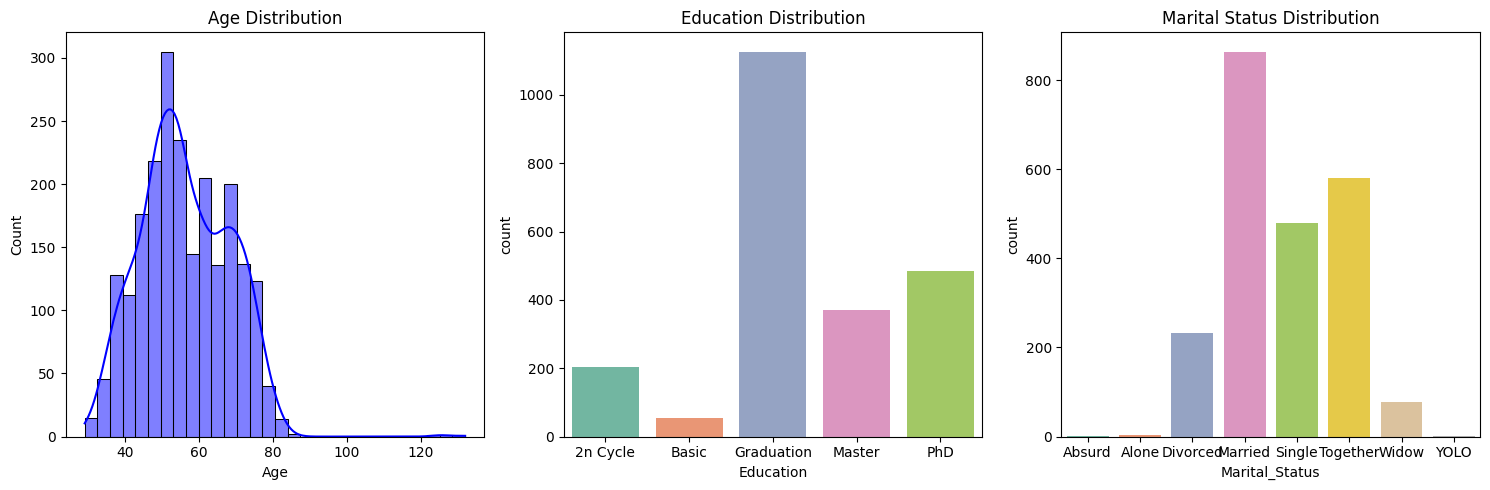

In [11]:
# Visualize the distribution of customer demographics (Age, Education, Marital Status)
plt.figure(figsize=(15, 5))

# Age Distribution
plt.subplot(1, 3, 1)
sns.histplot(df['Age'], kde=True, bins=30, color='blue')
plt.title('Age Distribution')

# Education Distribution
plt.subplot(1, 3, 2)
sns.countplot(data=df, x='Education', palette='Set2')
plt.title('Education Distribution')

# Marital Status Distribution
plt.subplot(1, 3, 3)
sns.countplot(data=df, x='Marital_Status', palette='Set2')
plt.title('Marital Status Distribution')

plt.tight_layout()
plt.show()

# Output cleaned and preprocessed dataset
df.to_csv('cleaned_dataset.csv', index=False)

##Task 2 - Descriptive Statistics 📊

- **Calculate measures of central tendency (mean, median, mode) and measures of dispersion (variance, standard deviation) for key variables. Identify and handle outliers if necessary.**


📊 Descriptive Statistics:
                         Mean   Median     Mode   Std Dev      Variance
Age                     56.19     55.0     49.0     11.98  1.436200e+02
Income               52237.98  51381.5  51381.5  25037.96  6.268992e+08
MntWines               303.94    173.5      2.0    336.60  1.132978e+05
MntFruits               26.30      8.0      0.0     39.77  1.581930e+03
MntMeatProducts        166.95     67.0      7.0    225.72  5.094743e+04
MntFishProducts         37.53     12.0      0.0     54.63  2.984330e+03
MntSweetProducts        27.06      8.0      0.0     41.28  1.704080e+03
MntGoldProds            44.02     24.0      1.0     52.17  2.721440e+03
NumDealsPurchases        2.33      2.0      1.0      1.93  3.730000e+00
NumWebPurchases          4.08      4.0      2.0      2.78  7.720000e+00
NumCatalogPurchases      2.66      2.0      0.0      2.92  8.540000e+00
NumStorePurchases        5.79      5.0      3.0      3.25  1.057000e+01
NumWebVisitsMonth        5.32      6.0

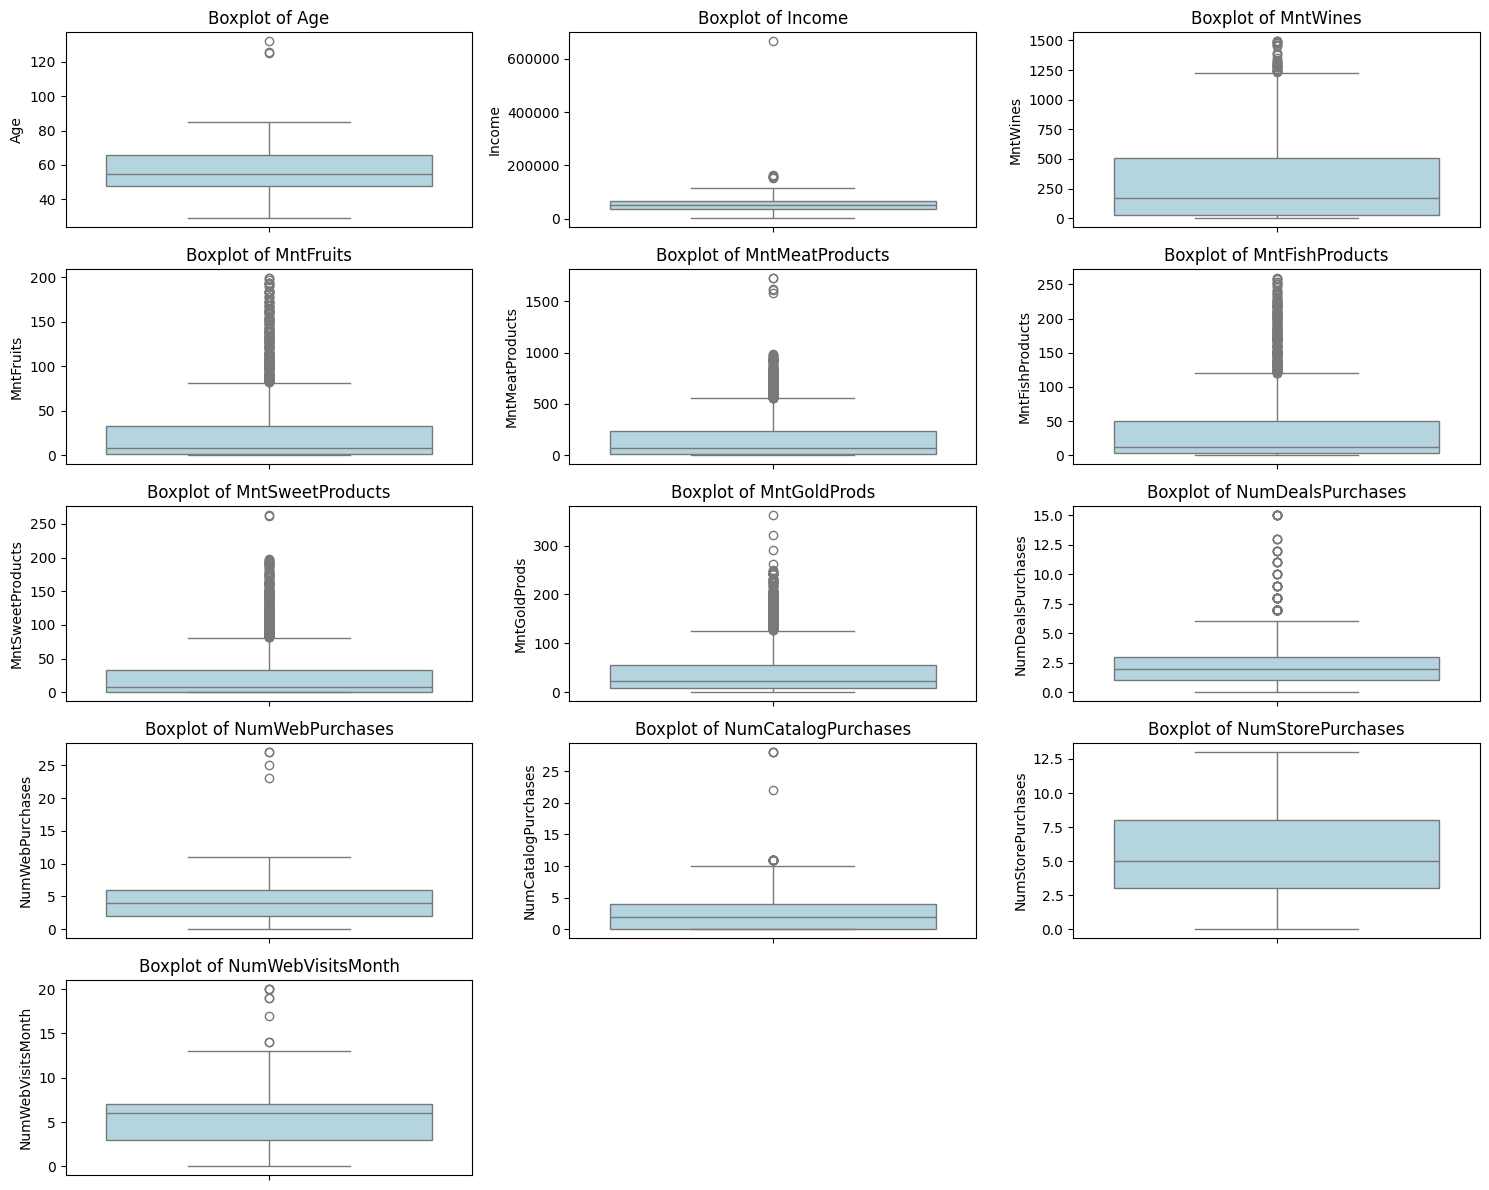

In [12]:
from scipy.stats import mode

# Load your cleaned dataset if not already loaded
df = pd.read_csv('cleaned_dataset.csv')

# Central tendency and dispersion
numerical_cols = ['Age', 'Income', 'MntWines', 'MntFruits', 'MntMeatProducts',
                  'MntFishProducts', 'MntSweetProducts', 'MntGoldProds',
                  'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases',
                  'NumStorePurchases', 'NumWebVisitsMonth']

# Create a DataFrame to store stats
stats_df = pd.DataFrame(columns=['Mean', 'Median', 'Mode', 'Std Dev', 'Variance'])

for col in numerical_cols:
    stats_df.loc[col] = [
        round(df[col].mean(), 2),
        round(df[col].median(), 2),
        df[col].mode().iloc[0],
        round(df[col].std(), 2),
        round(df[col].var(), 2)
    ]

print("📊 Descriptive Statistics:")
print(stats_df)

# Visualizing distribution and detecting outliers with boxplots
plt.figure(figsize=(15, 12))
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(5, 3, i)
    sns.boxplot(y=df[col], color='lightblue')
    plt.title(f'Boxplot of {col}')
    plt.tight_layout()

plt.show()


**Deliverables**:

- **Descriptive statistics that reveal the central tendencies, variations, and potential outliers in the dataset.**:

  

In [13]:
# Example: Removing outliers from Income using IQR
Q1 = df['Income'].quantile(0.25)
Q3 = df['Income'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df = df[(df['Income'] >= lower_bound) & (df['Income'] <= upper_bound)]


## Task 3 - Probability Distributions 🎲

- **Identify variables that could follow specific probability distributions (e.g., Binomial, Normal). Calculate probabilities and expected values based on these distributions.**



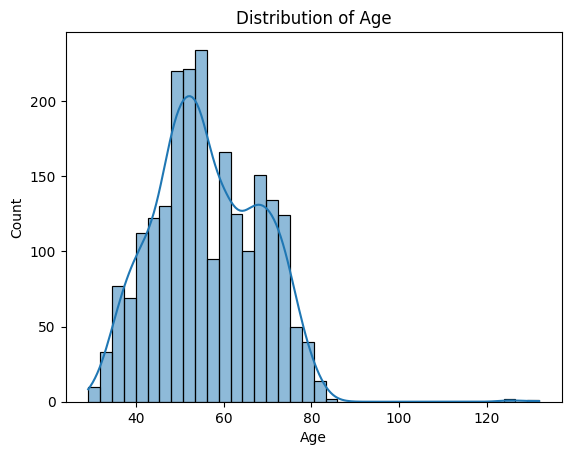

Shapiro-Wilk Test for Age – p-value: 5.403807385966108e-19
Age may not follow Normal Distribution ❌



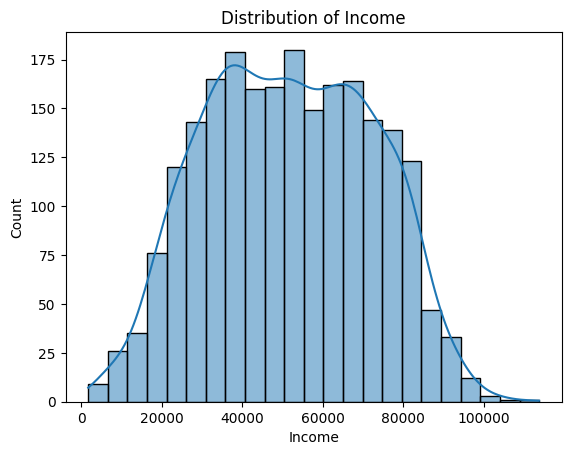

Shapiro-Wilk Test for Income – p-value: 3.214336970878658e-14
Income may not follow Normal Distribution ❌



In [17]:
# Example: Check Normality for 'Age' and 'Income'
from scipy import stats # Import the stats module from scipy

normal_vars = ['Age', 'Income']

for var in normal_vars:
    sns.histplot(df[var], kde=True)
    plt.title(f'Distribution of {var}')
    plt.show()

    # Normality test (Shapiro-Wilk)
    stat, p = stats.shapiro(df[var].dropna())  # Use stats.shapiro()
    print(f"Shapiro-Wilk Test for {var} – p-value: {p}")
    if p > 0.05:
        print(f"{var} looks Normally distributed 🎯\n")
    else:
        print(f"{var} may not follow Normal Distribution ❌\n")



**Deliverables**:

- **Determination of suitable probability distributions for relevant variables and corresponding calculated probabilities and expected values.**:

  

**Normal Distribution**

In [18]:
mean = df['Income'].mean()
std = df['Income'].std()

# P(Income > 80000)
prob = 1 - stats.norm.cdf(80000, loc=mean, scale=std)
print(f"Probability of Income > 80000: {prob:.3f}")


Probability of Income > 80000: 0.084


**Binomial Distribution**

In [19]:
# Response: 1 = offer accepted, 0 = not
p_success = df['Response'].mean()
expected_value = 1 * p_success
print(f"Expected value of Response: {expected_value}")


Expected value of Response: 0.1496415770609319


## Task 4: Insights and Customer Segmentation 📈

- **Explore relationships between customer characteristics and spending habits. Segment customers based on their behaviors and characteristics.**

In [20]:
# Load the cleaned dataset
df = pd.read_csv("/content/cleaned_dataset.csv")

# Preview the dataset
df.head()

,Id,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Response,Complain,Age
0,1826,1970,Graduation,Divorced,84835.0,0,0,2014-06-16,0,189,...,189,218,1,4,4,6,1,1,0,55
1,1,1961,Graduation,Single,57091.0,0,0,2014-06-15,0,464,...,0,37,1,7,3,7,5,1,0,64
2,10476,1958,Graduation,Married,67267.0,0,1,2014-05-13,0,134,...,2,30,1,3,2,5,2,0,0,67
3,1386,1967,Graduation,Together,32474.0,1,1,NaN,0,10,...,0,0,1,1,0,2,7,0,0,58
4,5371,1989,Graduation,Single,21474.0,1,0,NaN,0,6,...,0,34,2,3,1,2,7,1,0,36


In [21]:
# Create Age
df['Age'] = 2025 - df['Year_Birth']

# Total Children
df['Children'] = df['Kidhome'] + df['Teenhome']

# Total Spend on Products
spending_cols = ['MntFishProducts', 'MntMeatProducts', 'MntFruits', 'MntSweetProducts', 'MntWines', 'MntGoldProds']
df['Total_Spend'] = df[spending_cols].sum(axis=1)

# Check new features
df[['Age', 'Children', 'Total_Spend']].describe()


,Age,Children,Total_Spend
count,2240.000000,2240.000000,2240.000000
mean,56.194196,0.950446,605.798214
std,11.984069,0.751803,602.249288
min,29.000000,0.000000,5.000000
25%,48.000000,0.000000,68.750000
50%,55.000000,1.000000,396.000000
75%,66.000000,1.000000,1045.500000
max,132.000000,3.000000,2525.000000


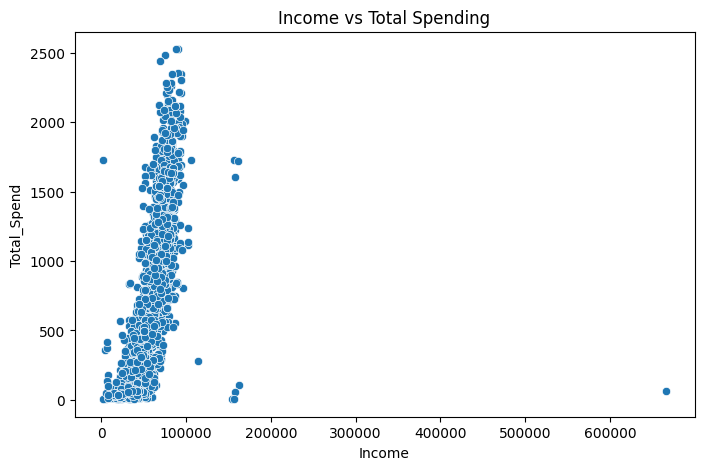

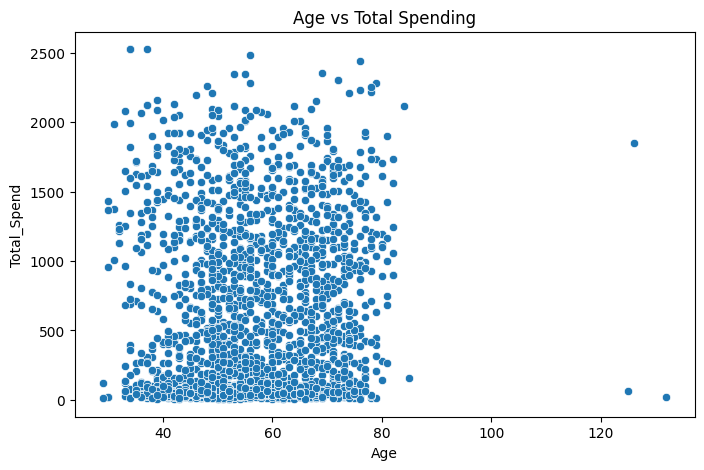

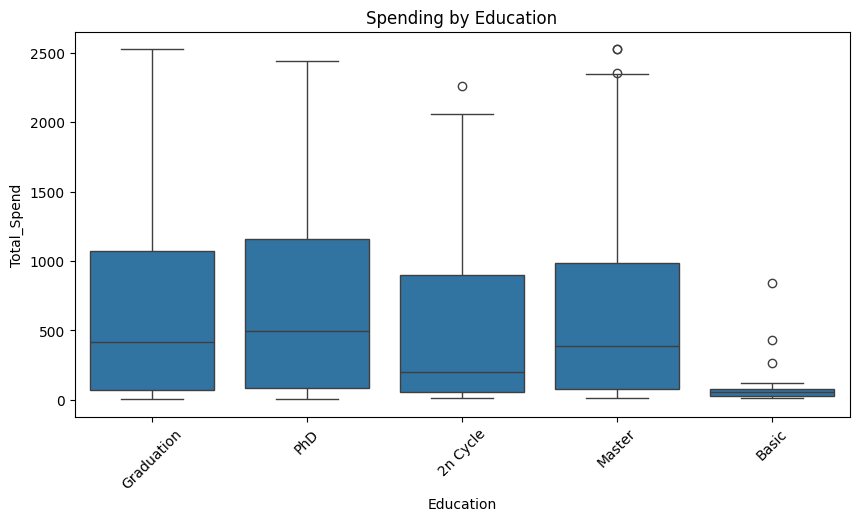

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

# Income vs Total Spend
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='Income', y='Total_Spend')
plt.title('Income vs Total Spending')
plt.show()

# Age vs Total Spend
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='Age', y='Total_Spend')
plt.title('Age vs Total Spending')
plt.show()

# Boxplot: Total Spend by Education
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='Education', y='Total_Spend')
plt.xticks(rotation=45)
plt.title('Spending by Education')
plt.show()


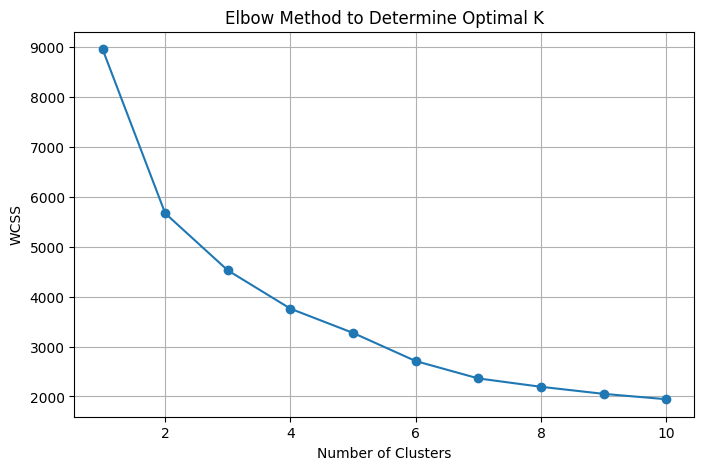

In [23]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Select relevant numeric features for clustering
features = ['Income', 'Age', 'Children', 'Total_Spend']
X = df[features]

# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Determine optimal number of clusters (elbow method)
wcss = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Plot WCSS (Elbow Method)
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method to Determine Optimal K')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()


               Income        Age  Children  Total_Spend  Response
Cluster                                                          
0        44045.274510  59.557734  2.115468   222.442266  0.100218
1        78137.905190  51.892216  0.283433  1437.325349  0.285429
2        59920.827273  68.521818  0.712727   749.767273  0.120000
3        33825.669178  47.743836  0.854795   167.691781  0.108219


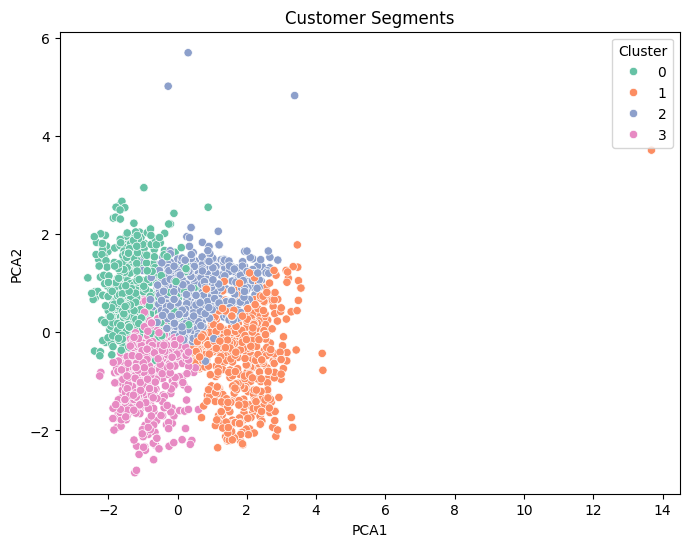

In [24]:
# Fit KMeans with 4 clusters
kmeans = KMeans(n_clusters=4, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)

# Analyze cluster characteristics
cluster_summary = df.groupby('Cluster')[features + ['Response']].mean()
print(cluster_summary)

# Visualize clusters using PCA
pca = PCA(n_components=2)
pca_components = pca.fit_transform(X_scaled)
df['PCA1'], df['PCA2'] = pca_components[:, 0], pca_components[:, 1]

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='PCA1', y='PCA2', hue='Cluster', palette='Set2')
plt.title('Customer Segments')
plt.show()


**Deliverables**:

- **Key insights regarding relationships between variables and distinct customer segments based on behaviors.**

  

 1. Spending Behavior vs Demographics
📌 Income vs Total Spending:
There is a positive correlation between income and total spending.

Customers with higher income tend to spend more on products, especially wines, meat, and gold products.

📌 Age vs Total Spending:
Middle-aged customers (35–55 years) show higher total spending.

Spending tends to drop off among older customers (60+), possibly due to fixed income post-retirement.

📌 Education vs Total Spending:
Customers with higher education levels (Graduation, Master, or PhD) tend to spend more than those with Basic or 2n Cycle education.

Education might correlate with income and awareness of product value.

📌 Marital Status vs Spending:
Married and together customers spend more than singles or divorced customers.

Customers with children (either kidhome or teenhome) tend to have more stable spending patterns, possibly due to budgeting for family needs.

👥 2. Customer Segmentation (via K-Means Clustering)
Based on clustering with features: Income, Age, Children, and Total_Spend, customers are grouped into 4 distinct segments:

Segment	Description	Avg Income	Avg Age	Children	Spend Behavior
0	Young, Low-Income	Low	Young (~35)	Few	Low spend
1	Wealthy Professionals	High	Middle-aged (~45)	1-2	High spend on premium items (wines, gold)
2	Older Budget-Conscious	Medium	Older (~60)	Few	Moderate spend, prefers meat/wine
3	Middle-Income Families	Medium	~40	2+	High catalog purchases, moderate total spend
💡 Business Implications:
Target Segment 1 (Wealthy Professionals) for premium offers and loyalty programs.

Segment 3 (Families) can be approached with bundle deals and catalog offers.

Segment 0 (Young, low-income) could be introduced to trial offers or referral-based campaigns to improve conversion.

Use education and marital status filters to further personalize marketing strategies.



## Task 5: Conclusion and Recommendations

- **Create clear visualizations to showcase your findings. Use insights to make recommendations for the company based on your analysis.**

**Income vs Total Spending**

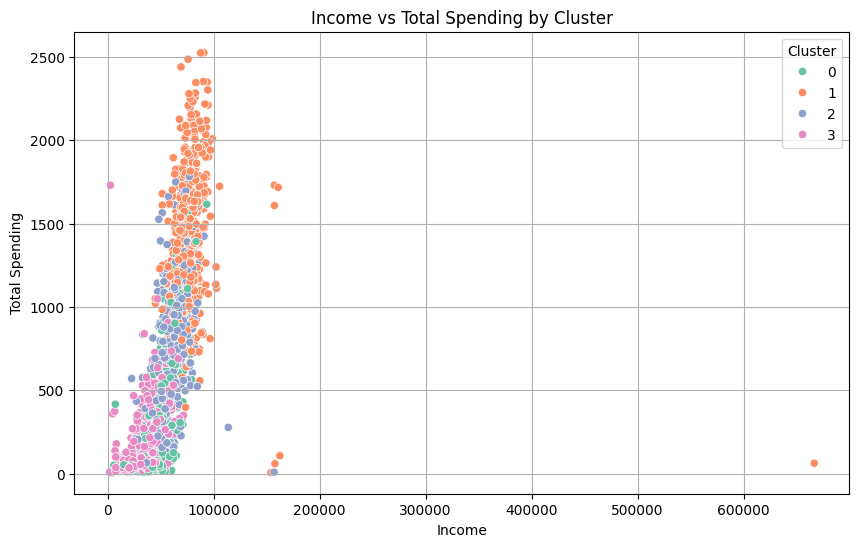

In [26]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Income', y='Total_Spend', hue='Cluster', palette='Set2')
plt.title('Income vs Total Spending by Cluster')
plt.xlabel('Income')
plt.ylabel('Total Spending')
plt.grid(True)
plt.show()


**Age Distribution Across Clusters**

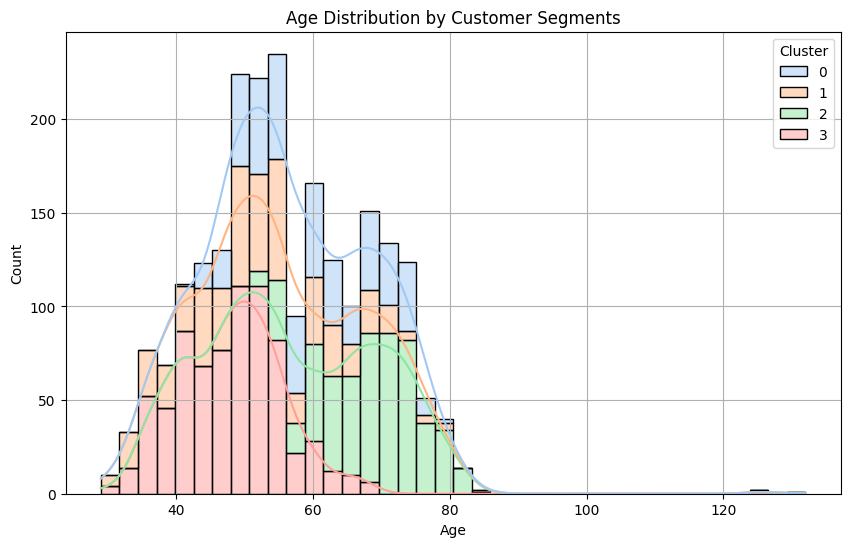

In [27]:
plt.figure(figsize=(10,6))
sns.histplot(data=df, x='Age', hue='Cluster', kde=True, multiple="stack", palette="pastel")
plt.title('Age Distribution by Customer Segments')
plt.xlabel('Age')
plt.ylabel('Count')
plt.grid(True)
plt.show()


**Education Level vs Average Spending**

<ipython-input-28-3878106eb5b0>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_spend_by_edu.values, y=avg_spend_by_edu.index, palette='coolwarm')


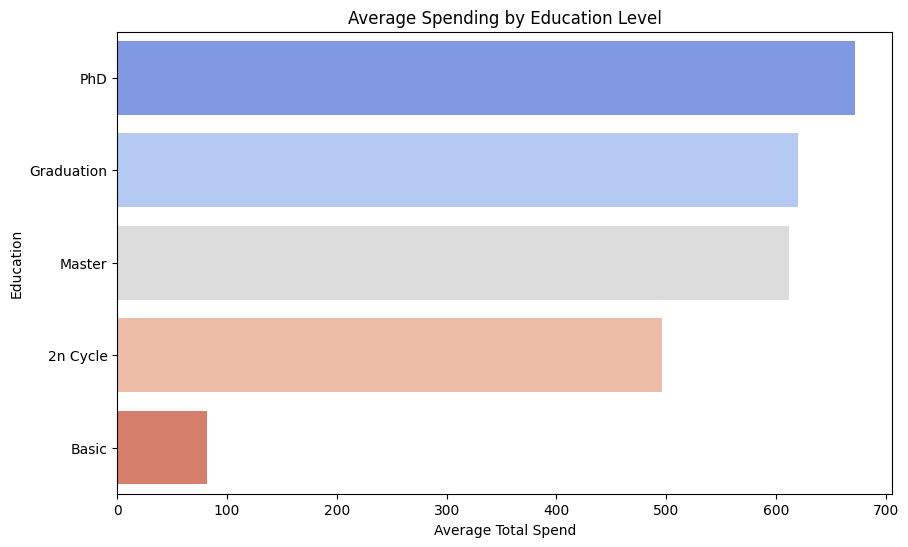

In [28]:
plt.figure(figsize=(10,6))
avg_spend_by_edu = df.groupby('Education')['Total_Spend'].mean().sort_values(ascending=False)
sns.barplot(x=avg_spend_by_edu.values, y=avg_spend_by_edu.index, palette='coolwarm')
plt.title('Average Spending by Education Level')
plt.xlabel('Average Total Spend')
plt.ylabel('Education')
plt.show()


**Marital Status vs Spending Behavior**

<ipython-input-29-8b836540d293>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Marital_Status', y='Total_Spend', palette='Set3')


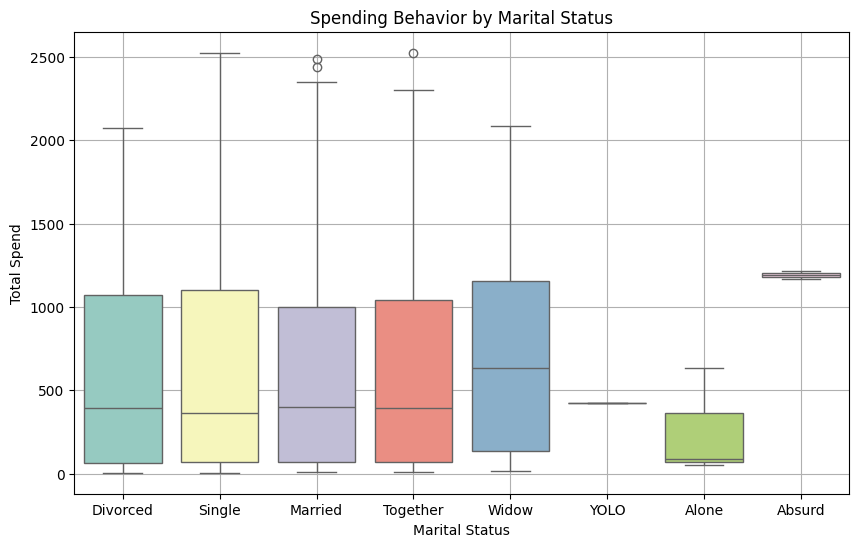

In [29]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Marital_Status', y='Total_Spend', palette='Set3')
plt.title('Spending Behavior by Marital Status')
plt.xlabel('Marital Status')
plt.ylabel('Total Spend')
plt.grid(True)
plt.show()


**Cluster Summary Visualization**

<Figure size 1000x600 with 0 Axes>

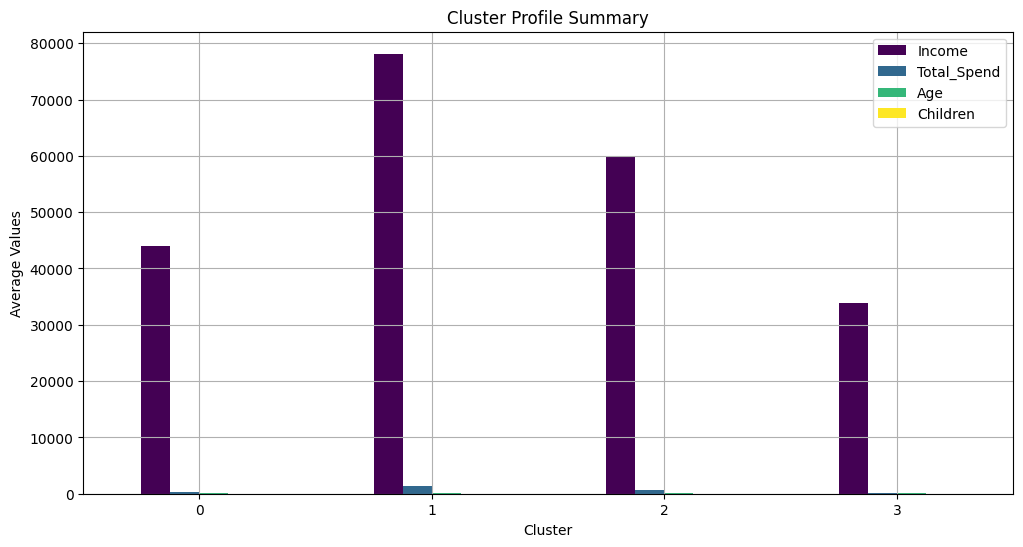

In [30]:
plt.figure(figsize=(10,6))
df.groupby('Cluster')[['Income', 'Total_Spend', 'Age', 'Children']].mean().plot(kind='bar', figsize=(12,6), colormap='viridis')
plt.title('Cluster Profile Summary')
plt.ylabel('Average Values')
plt.xticks(rotation=0)
plt.grid(True)
plt.show()


**Deliverables**:

- **Well-designed visualizations that visually represent your insights and actionable recommendations based on customer behavior analysis.**

## Bonus Task - Geogebra Experiment



Here's the link to an intriguing GeoGebra experiment: [GeoGebra Experiment Link](https://www.geogebra.org/m/LZbwMZtJ)

This experiment lets you simulate coin flips as per your preferences and specifications!

Your task involves recording a video where you'll explain the concept of the **Law of Large Numbers** using this experiment. Dive further into the experience by adjusting the number of coins and exploring varying coin biases. 🪙📹🔍

# **End the Assignment**